In [35]:
!pip install arch
# yfinance

In [36]:
import gpytorch as gp, sklearn as sk, numpy as np, matplotlib.pyplot as plt, arch
from statsmodels.graphics.tsaplots import plot_acf

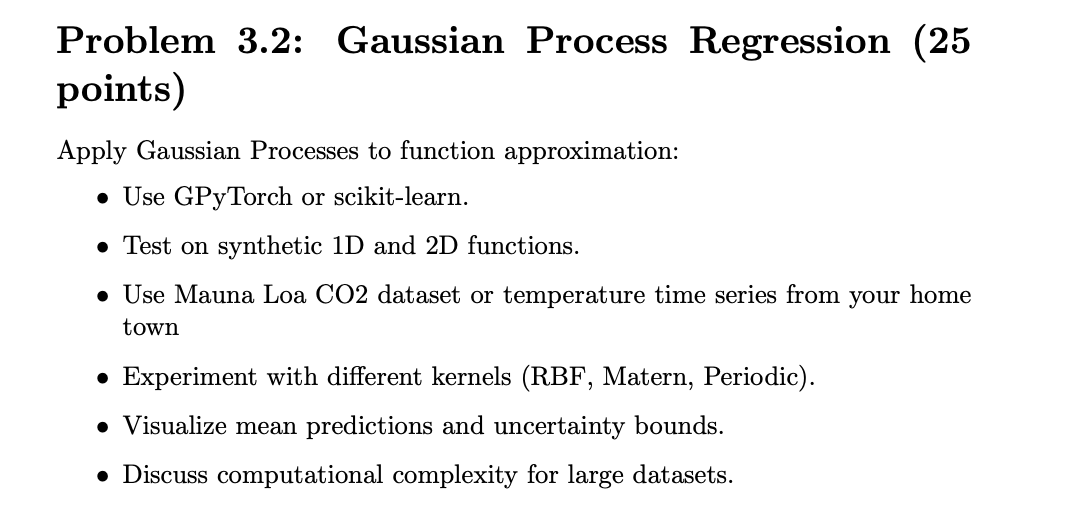

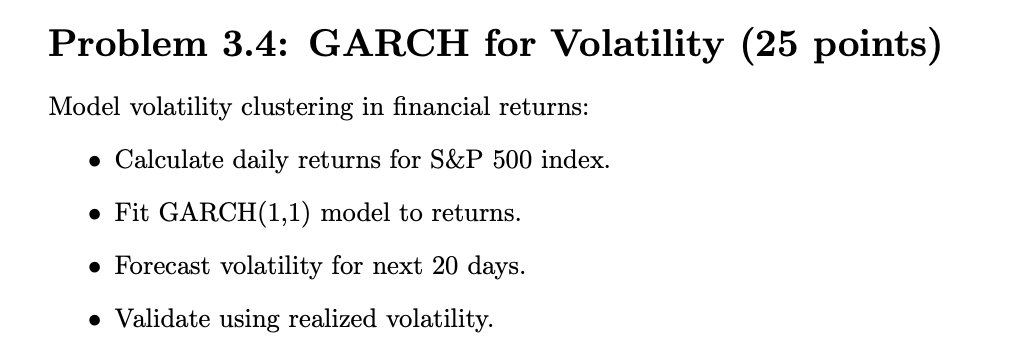

In [8]:
import yfinance as yf
import pandas as pd

# Download 10+ years of S&P 500 data (ticker: ^GSPC)
sp500 = yf.download('^GSPC', start='2014-01-01', end=None)
sp500.to_csv('sp500_10y.csv')  # Save to CSV if needed
sp500.info()

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3096 entries, 2014-01-02 to 2026-04-24
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, ^GSPC)   3096 non-null   float64
 1   (High, ^GSPC)    3096 non-null   float64
 2   (Low, ^GSPC)     3096 non-null   float64
 3   (Open, ^GSPC)    3096 non-null   float64
 4   (Volume, ^GSPC)  3096 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 145.1 KB


In [126]:
df_all = pd.read_csv("/Users/marysia/Desktop/applied/ml/apl_math/sp500_10y.csv", index_col=0, parse_dates=True)
df = df_all[['Close']]
df['ret'] = 100 * np.log(df['Close']/df['Close'].shift(1))
train, test = df[:-20], df[-20:]

/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_37790/3810816034.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ret'] = 100 * np.log(df['Close']/df['Close'].shift(1))


Text(0.5, 1.0, 'Returns - train set')

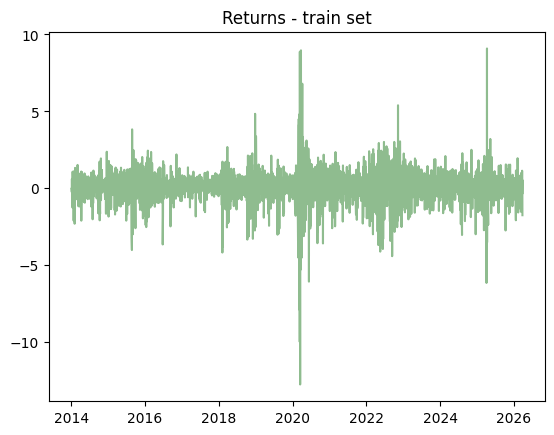

In [127]:
plt.plot(train["ret"], color = 'darkseagreen')
plt.title('Returns - train set')

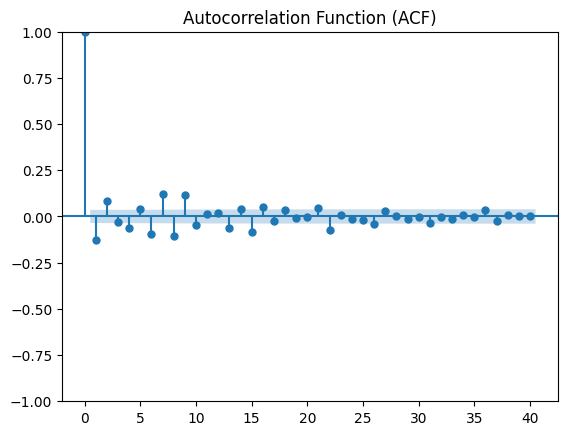

In [33]:
plot_acf(train['ret'].dropna(), lags=40)
plt.title('Autocorrelation Function (ACF)')
plt.show()

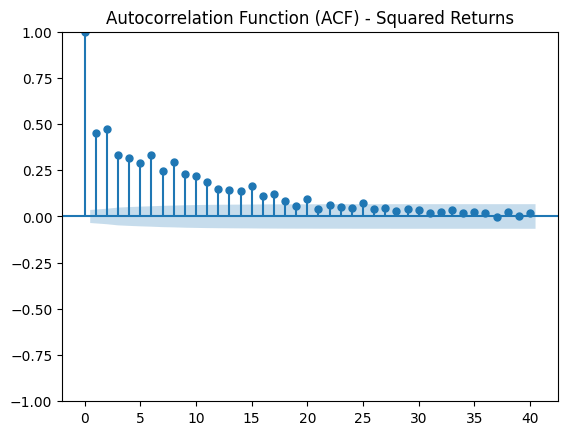

In [116]:
plot_acf(train['ret'].dropna()**2, lags=40)
plt.title('Autocorrelation Function (ACF) - Squared Returns')
plt.show()

In [115]:
model = arch.arch_model(train['ret'][1:], vol="Garch", p=1, q=1, mean="Constant", dist="Normal").fit()
model

Iteration:      1,   Func. Count:      6,   Neg. LLF: 59985573235223.09
Iteration:      2,   Func. Count:     15,   Neg. LLF: 1690419199.13022
Iteration:      3,   Func. Count:     22,   Neg. LLF: 5094.697416323366
Iteration:      4,   Func. Count:     28,   Neg. LLF: 4585.281406384339
Iteration:      5,   Func. Count:     35,   Neg. LLF: 6586.191478900551
Iteration:      6,   Func. Count:     41,   Neg. LLF: 3906.943311390041
Iteration:      7,   Func. Count:     46,   Neg. LLF: 3906.8001227222185
Iteration:      8,   Func. Count:     51,   Neg. LLF: 3906.787782190003
Iteration:      9,   Func. Count:     56,   Neg. LLF: 3906.787690402715
Iteration:     10,   Func. Count:     61,   Neg. LLF: 3906.787688254366
Iteration:     11,   Func. Count:     65,   Neg. LLF: 3906.787688254666
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3906.787688254366
            Iterations: 11
            Function evaluations: 65
            Gradient evaluations: 11

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                    ret   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3906.79
Distribution:                  Normal   AIC:                           7821.58
Method:            Maximum Likelihood   BIC:                           7845.70
                                        No. Observations:                 3075
Date:                Sat, Apr 25 2026   Df Residuals:                     3074
Time:                        15:21:39   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0745  1.331e-02      5.601  2.129e-08 [4.846e-0

In [129]:
train = train.copy()
train['sigma'] = model.conditional_volatility
omega = model.params['omega']
alpha = model.params['alpha[1]']
beta = model.params['beta[1]']
resid = model.resid
mean = model.params['mu']
sigmas = [model.conditional_volatility[0]]
for t in range(1, len(resid)):
    sigma2 = omega + alpha * resid[t-1]**2 + beta * sigmas[-1]**2
    sigmas.append(np.sqrt(sigma2))

train['sigma_manual'] = [None]+sigmas

/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_37790/1929151380.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sigmas = [model.conditional_volatility[0]]
/var/folders/7f/qnqr5kmj7z9b_f11s8sp00v80000gn/T/ipykernel_37790/1929151380.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sigma2 = omega + alpha * resid[t-1]**2 + beta * sigmas[-1]**2


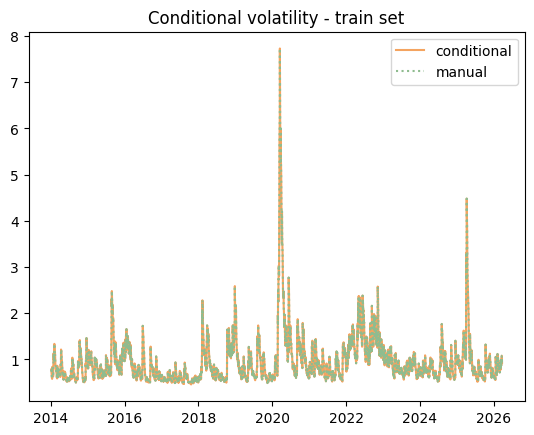

In [130]:
plt.plot(train['sigma'], color='sandybrown', label="conditional")
plt.plot(train['sigma_manual'], label="manual", ls=':', color = 'darkseagreen')
plt.title("Conditional volatility - train set");plt.legend()

In [131]:
train['std_ret'] = (train['ret'] - mean) / train['sigma']

Text(0.5, 1.0, 'Standarized returns - train set')

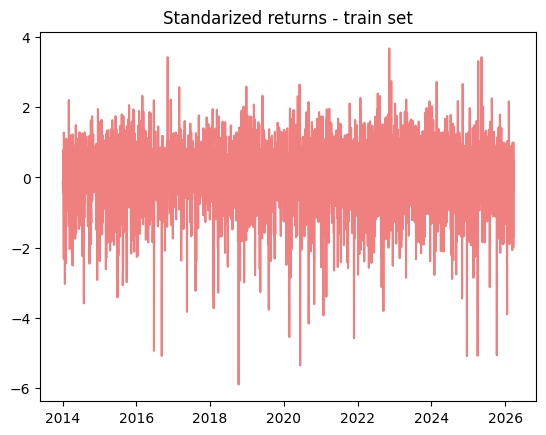

In [132]:
plt.plot(train['std_ret'], color='lightcoral');plt.title("Standarized returns - train set")

In [133]:
Z = np.random.normal(0,1,len(train))
train['test'] = Z

Text(0.5, 1.0, 'Standarized returns vs N(0,1) - train set')

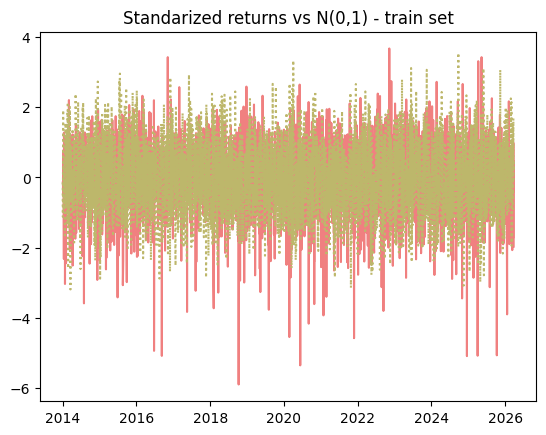

In [134]:
plt.plot(train['std_ret'], color='lightcoral', label = 'Std returns')
plt.plot(train['test'], color='darkkhaki', ls=':', label = 'N(0,1)')
plt.title("Standarized returns vs N(0,1) - train set")

In [135]:
from scipy.stats import shapiro, jarque_bera

# Shapiro-Wilk test
stat, p = shapiro(train['std_ret'].dropna())
print(f"Shapiro-Wilk test: statistic={stat:.4f}, p-value={p:.4f}")

# Jarque-Bera test
jb_stat, jb_p = jarque_bera(train['std_ret'].dropna())
print(f"Jarque-Bera test: statistic={jb_stat:.4f}, p-value={jb_p:.4f}")

Shapiro-Wilk test: statistic=0.9687, p-value=0.0000
Jarque-Bera test: statistic=995.0465, p-value=0.0000


In [136]:
forecast = model.forecast(horizon=20)
forecast_vol = np.sqrt(forecast.variance)
realized_vol = train['ret'].rolling(window=20).std()

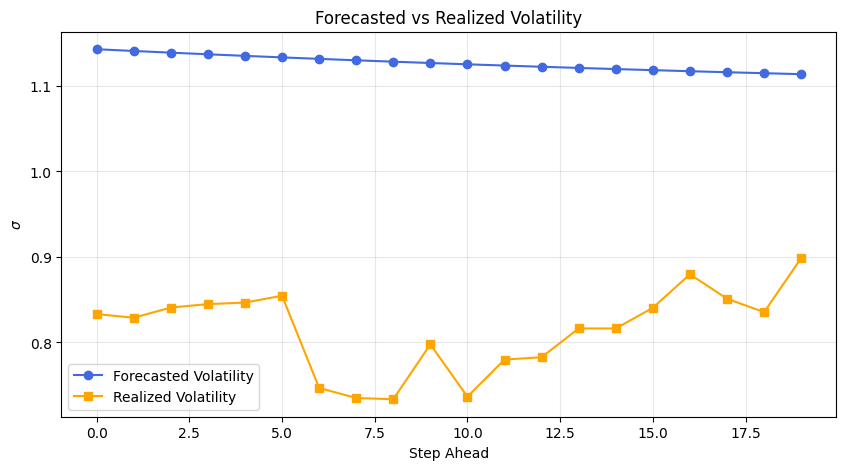

In [137]:
plt.figure(figsize=(10, 5))
plt.plot(forecast_vol.values[-1], marker='o', color='royalblue', label='Forecasted Volatility')
plt.plot(realized_vol[-20:].values, marker='s', color='orange', label='Realized Volatility')
plt.title('Forecasted vs Realized Volatility')
plt.xlabel('Step Ahead')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [138]:
def garman_klass(df):
    log_hl = np.log(df['High'] / df['Low'])
    log_co = np.log(df['Close'] / df['Open'])
    variance = 0.5*(log_hl ** 2) - (2 * np.log(2) - 1) * (log_co ** 2)
    return np.sqrt(variance)*100

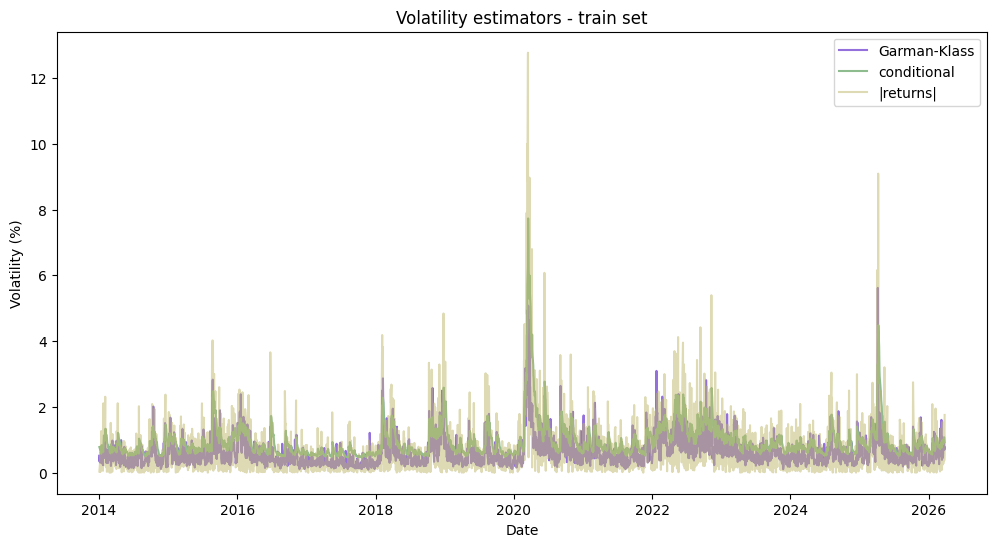

In [145]:
GK = garman_klass(df_all)
plt.figure(figsize=(12, 6))
plt.plot(GK[:-20], color='mediumpurple', label = 'Garman-Klass')
plt.plot(train['sigma'], label="conditional", color = 'darkseagreen')
plt.plot(np.abs(train['ret']), color='darkkhaki', label="|returns|", alpha=0.5)
plt.title('Volatility estimators - train set')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.legend()
plt.show()